In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score)
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('heart_disease.csv')

In [14]:
# Task 1

print(df.shape)
df.head()


# This is a classification problem and binary because we are predicting whether or not a patient has heart disease
# This can only be has heart disease or does not have heart disesase

(270, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,1,0


In [15]:
# Task 2

disease_yes = round(((df['target'].value_counts()[1]) / df.shape[0]) * 100, 1)
disease_no = round(((df['target'].value_counts()[0]) / df.shape[0]) * 100, 1)

print(f"Patients with heart disease: {disease_yes}%")
print(f"Patients without heart disease: {disease_no}%")

# A lazy model would get 55.6% of guesses correct
# For medical diagnosis, it's much more dangerous to miss a diagnosis than to misidentify one

Patients with heart disease: 44.4%
Patients without heart disease: 55.6%


In [16]:
# Task 3

X = df[['age', 'trestbps', 'chol', 'thalach']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [17]:
# Task 4

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

pred = pd.DataFrame(lr_model.predict(X_test))
perc = pd.DataFrame(lr_model.predict_proba(X_test))

perc_med = perc.median()

print(f"Prediction: {pred}")

print(f"Predicted % of heart disease: {perc_med[0]:.2}%")

Prediction:     0
0   0
1   0
2   0
3   0
4   1
5   0
6   0
7   0
8   0
9   1
10  1
11  0
12  1
13  1
14  1
15  0
16  1
17  0
18  0
19  0
20  1
21  0
22  1
23  0
24  0
25  1
26  0
27  0
28  0
29  0
30  0
31  0
32  0
33  0
34  0
35  1
36  0
37  0
38  1
39  1
40  1
41  0
42  1
43  0
44  0
45  0
46  0
47  1
48  1
49  0
50  1
51  0
52  0
53  1
Predicted % of heart disease: 0.59%


In [18]:
# Task 5

print(pred.head(5))
perc.head(5)

# Very sure about the 3rd patient with 83% and unsure about the 1st and 2nd, both close to 50%

   0
0  0
1  0
2  0
3  0
4  1


,0,1
0,0.589066,0.410934
1,0.536894,0.463106
2,0.839802,0.160198
3,0.744548,0.255452
4,0.421834,0.578166


In [19]:
# Task 6

model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Training Data Accuracy: {accuracy_score(y_train, y_pred_train)}")

# DecisionTree scores very high on training data compared to test data because it becomes overfit

Accuracy: 0.5370370370370371
Training Data Accuracy: 0.9675925925925926


In [20]:
# Scores for later question

dt_accuracy = accuracy_score(y_test, y_pred)
dt_precision = precision_score(y_test, y_pred)
dt_recall = recall_score(y_test, y_pred)
dt_f1 = f1_score(y_test, y_pred)

People model said were healthy but not: 10


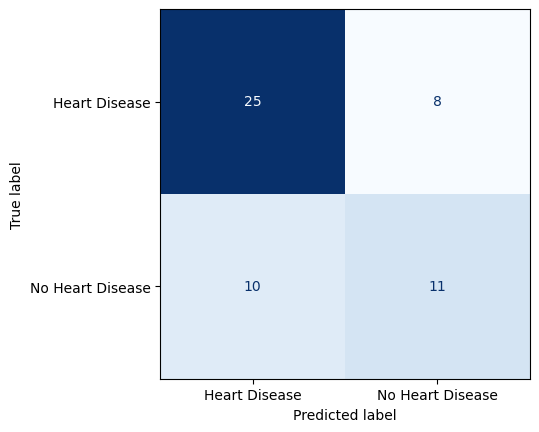

In [21]:
#Task 7

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=["Heart Disease", "No Heart Disease"],
    cmap="Blues",
    colorbar=False
)
tp, fp, fn, tn = cm.ravel()

print("People model said were healthy but not:", fn)
#

In [22]:
#Task 8

lr_precision = precision_score(y_test, pred)
lr_recall = recall_score(y_test, pred)
print("Precision:", lr_precision)
print("Recall:", lr_recall)

#Of the times the model said the patient had heart disease, it was correct 58% of the time.
#The model only caught 52% of people with heart disease.
#It is better to use the recall number because heart disease is serious.

Precision: 0.5789473684210527
Recall: 0.5238095238095238


In [23]:
#Advanced task 1
proba = lr_model.predict_proba(X_test)[:, 1]

threshold = .3
y_pred_low = (proba >= threshold).astype(int)

lr_accuracy = accuracy_score(y_test, y_pred_low)
lr_precision = precision_score(y_test, y_pred_low)
lr_recall = recall_score(y_test, y_pred_low)
lr_f1 = f1_score(y_test, y_pred_low)

print("Precision:", lr_precision)
print("Recall:", lr_recall)



Precision: 0.5405405405405406
Recall: 0.9523809523809523


Recall flagged a lot more people with heart disease. Precision got less accurate. In this scenario it is better to use the recall number because you don't want to miss people with heart disease.

In [26]:
# Advanced Task 2

print("Decision Tree")
print(f"Accuracy: {dt_accuracy}")
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print(f"F1 Score: {dt_f1}")

print("\nLogistic Regression")
print(f"Accuracy: {lr_accuracy}")
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print(f"F1 Score: {lr_f1}")

Decision Tree
Accuracy: 0.5370370370370371
Precision: 0.3888888888888889
Recall: 0.3333333333333333
F1 Score: 0.358974358974359

Logistic Regression
Accuracy: 0.6666666666666666
Precision: 0.5405405405405406
Recall: 0.9523809523809523
F1 Score: 0.6896551724137931


Logistic regression is the model that we would recommend for prediction. The recall is especially high on this model, being favorable for finding people who potentially have heart disease. For this specific scenario, missing people with heart disease is much more detrimental than flagging false positives. Regarding the other metrics, they are also all higher then the Decision Tree.

In [36]:
# Task 11

import numpy as np
import pandas as pd

from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error



def create_pipeline(numeric_cols):
    numeric_pipeline = Pipeline([
        ("scaler", StandardScaler()),
    ])

    column_processor = ColumnTransformer([
        ('numeric', numeric_pipeline, numeric_cols),
    ])

    return Pipeline([
        ('preprocessor', column_processor),
        ('model', LinearRegression())
    ])


# Calling the function
numeric_cols = ['age', 'trestbps', 'chol', 'thalach']

X = df[['age', 'trestbps', 'chol', 'thalach']]
y = df['target']


# Split data
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42)


# Create pipeline
pipe = create_pipeline(numeric_cols)
pipe.fit(X_temp, y_temp)

y_pred = pipe.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred)
lr_precision = precision_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)

# Evaluate

print("Pipeline")
print(f"Accuracy: {lr_accuracy}")
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print(f"F1 Score: {lr_f1}")

ValueError: Classification metrics can't handle a mix of binary and continuous targets